# Lean specification fidelity — Modal experiment

Qwen3-4B-Instruct-2507 + LoRA and a binary classification head, trained on one Modal A100 80 GB. This notebook reads local reports; Run All never starts training.

For problem group $j$ with $n_j$ examples, label $y_i\in\{0,1\}$ and model logit $z_i$, the loss is

$$\mathcal L = \frac{1}{M}\sum_{j=1}^{M}\frac{1}{n_j}\sum_{i\in j}\left[\operatorname{softplus}(z_i)-y_i z_i\right].$$

Under uniform example sampling, each minibatch uses weight $w_i=N/(M n_j)$:

$$\widehat{\mathcal L}_B=\frac{1}{|B|}\sum_{i\in B} w_i\,\operatorname{BCEWithLogits}(z_i,y_i).$$

Only LoRA adapters and the classification head receive gradients. Development loss selects the checkpoint. A plateau means three development evaluations without a 0.001 improvement; it is not proof of convergence. The full run evaluates development loss every 50 optimizer steps and stops within one hour of submission, including loading/evaluation/saving. Calibration and the held-out final test run only after checkpoint selection. No final-test metrics guide training.


In [1]:
from pathlib import Path
import json, sys, inspect
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd()
if not (ROOT / "experiment.py").exists():
    ROOT = ROOT / "research" / "lean-fidelity"
sys.path.insert(0, str(ROOT))
import experiment
print(inspect.getsource(experiment.train))

def train(out, deadline=None, local=False):
    import time
    import torch
    from datasets import Dataset
    from peft import LoraConfig, TaskType, get_peft_model
    from transformers import (AutoModelForSequenceClassification, AutoTokenizer,
                              DataCollatorWithPadding, Trainer, TrainingArguments, TrainerCallback, set_seed)
    set_seed(42)
    if (out / "adapter").exists():
        raise FileExistsError("Adapter already exists; use a new experiment directory.")
    if local and not torch.backends.mps.is_available():
        raise RuntimeError("Apple Metal GPU is unavailable.")
    if not local and not torch.cuda.is_available():
        raise RuntimeError("This minimal training implementation requires a CUDA GPU; use Modal.")
    manifest = json.loads((out / "manifest.json").read_text())
    model_name = manifest.get("training_model", MODEL)
    tokenizer = AutoTokenizer.from_pretrained(model_name, revision=manifest["model_revision"])
    tokenizer.pad_

## Results
Stop at a development-loss plateau or the time/budget bound. A plateau is not a mathematical convergence guarantee. Missing results mean no completed report is available; do not substitute invented metrics.

In [2]:
runs = sorted((ROOT / "artifacts").glob("run-*"))
RUN = runs[-1] if runs else None
print("Latest report:", RUN or "No completed run downloaded")
if RUN:
    for name in ("run_status", "training_summary", "test_metrics"):
        path = RUN / f"{name}.json"
        if path.exists():
            value = json.loads(path.read_text())
            value.pop("training_metrics", None)  # Trainer throughput uses the nominal epoch ceiling.
            display(pd.Series(value, name=name).to_frame())

Latest report: /Users/masha/Documents/ChatGPT/AI x Science hackathon/research/lean-fidelity/artifacts/run-20261003T192204Z


,run_status
run_id,run-20261003T192204Z
budget_usd,20
deadline,1791058924.372241
rate_allowance_usd_hour,5
status,completed


,training_summary
optimizer_steps,400
stop_reason,development_loss_plateau
best_dev_loss,0.382258
training_seconds,1756.369566
gpu,NVIDIA A100-SXM4-80GB
model,Qwen/Qwen3-4B-Instruct-2507
peak_allocated_gib,7.923582
trainable_parameters,5900800
test_set_used,False


,test_metrics
rows,778.000000
coverage,0.020566
accepted,16.000000
wrong_accepted,0.000000
accepted_error,0.000000
brier,0.136980
threshold,0.827533


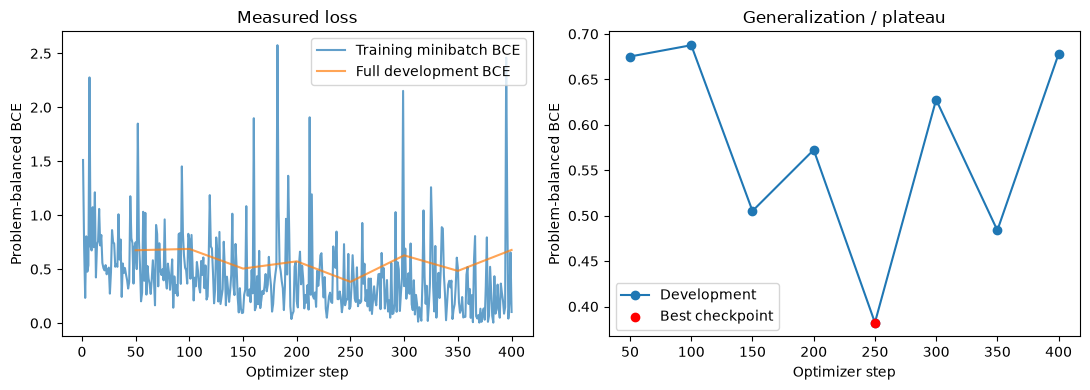

In [3]:
if RUN and (RUN / "training_metrics.json").exists():
    history = pd.DataFrame(json.loads((RUN / "training_metrics.json").read_text()))
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for key, label in (("loss", "Training minibatch BCE"), ("eval_loss", "Full development BCE")):
        if key in history:
            rows = history.dropna(subset=[key])
            axes[0].plot(rows["step"], rows[key], alpha=.7, label=label)
    axes[0].set(xlabel="Optimizer step", ylabel="Problem-balanced BCE", title="Measured loss")
    axes[0].legend()
    if "eval_loss" in history:
        dev = history.dropna(subset=["eval_loss"])
        axes[1].plot(dev["step"], dev["eval_loss"], marker="o", label="Development")
        if len(dev):
            best = dev.loc[dev["eval_loss"].idxmin()]
            axes[1].scatter([best["step"]], [best["eval_loss"]], color="red", zorder=5, label="Best checkpoint")
        axes[1].legend()
    axes[1].set(xlabel="Optimizer step", ylabel="Problem-balanced BCE", title="Generalization / plateau")
    fig.tight_layout()
    fig.savefig(RUN / "loss_curve.png", dpi=180)
    fig.savefig(RUN / "loss_curve.pdf")
    plt.show()
else:
    print("Loss measurements are not available yet.")


In [4]:
row = {"Model": "Qwen3-4B + LoRA", "Best dev BCE": None, "Steps": None, "Stop reason": "Not available", "Final test": "Not run"}
if RUN and (RUN / "training_summary.json").exists():
    summary = json.loads((RUN / "training_summary.json").read_text())
    row.update({"Best dev BCE": summary["best_dev_loss"], "Steps": summary["optimizer_steps"], "Stop reason": summary["stop_reason"]})
if RUN and (RUN / "test_metrics.json").exists():
    test = json.loads((RUN / "test_metrics.json").read_text())
    row.update({"Final test": "Held-out ID", "Coverage": test["coverage"], "Accepted error": test["accepted_error"], "Brier": test["brier"]})
display(pd.DataFrame([row]))


,Model,Best dev BCE,Steps,Stop reason,Final test,Coverage,Accepted error,Brier
0,Qwen3-4B + LoRA,0.382258,400,development_loss_plateau,Held-out ID,0.020566,0.0,0.13698


## Starting versus fine-tuned accuracy
Full train/test splits, probability threshold 0.5, no new optimizer updates. Starting means the original initialization reconstructed with seed 42 and the pinned model revision: pretrained backbone plus random binary head. It predicted every example as faithful. This is not a prompted Qwen baseline, and no initial checkpoint was saved. Test accuracy is the relevant generalization result; training accuracy is an in-sample diagnostic.


In [5]:
audit = json.loads((ROOT / "reports" / "accuracy-comparison.json").read_text())
accuracy = pd.DataFrame(audit["results"])
display(accuracy.pivot(index="model", columns="split", values="accuracy").map(lambda x: f"{x:.2%}"))
print("Prediction disagreements against original test evaluation:", audit["test_prediction_disagreements_vs_original"])
print(audit["consistency_note"])


split,test,train
model,,
fine_tuned,80.85%,90.77%
unfine_tuned,32.90%,29.85%


Prediction disagreements against original test evaluation: 6
Six test predictions differ from original batch-size-1 inference; total correct remains 629/778. BF16 batching can change scores around the decision boundary.


## External evaluation: no OOD tuning

CriticLeanBench supplies 450 published semantic labels (50 compilation failures excluded). The other four sets are **30 agent-authored contrast probes**, not independently labeled benchmarks. They contain 3–4 paired problems per library and mostly simple negation errors; no independent human audit or local Lean build was performed. Inputs were frozen and screened against all ProofNet splits before scoring.

Both accuracy columns use threshold 0.5. **Baseline means a reconstructed random binary head on pretrained Qwen, not prompted Qwen.** Source revisions, input hash, exclusions and per-source results are recorded in the report. No training or OOD calibration was performed.


model,fine_tuned,unfine_tuned
dataset,,
CriticLeanBench,62.67%,55.56%
Formal Conjectures probes,50.00%,50.00%
Lean Machine Learning probes,100.00%,50.00%
Tao Analysis I probes,100.00%,50.00%
Tao Equational Theories probes,100.00%,50.00%


,dataset,model,n,groups,correct,balanced_accuracy,tp,tn,fp,fn
0,CriticLeanBench,unfine_tuned,450,447,250,0.5005,249,1,199,1
1,CriticLeanBench,fine_tuned,450,447,282,0.6525,105,177,23,145
2,Formal Conjectures probes,unfine_tuned,6,3,3,0.5000,3,0,3,0
3,Formal Conjectures probes,fine_tuned,6,3,3,0.5000,0,3,0,3
4,Tao Analysis I probes,unfine_tuned,8,4,4,0.5000,4,0,4,0
5,Tao Analysis I probes,fine_tuned,8,4,8,1.0000,4,4,0,0
6,Tao Equational Theories probes,unfine_tuned,8,4,4,0.5000,4,0,4,0
7,Tao Equational Theories probes,fine_tuned,8,4,8,1.0000,4,4,0,0
8,Lean Machine Learning probes,unfine_tuned,8,4,4,0.5000,4,0,4,0
9,Lean Machine Learning probes,fine_tuned,8,4,8,1.0000,4,4,0,0


Paired CriticLeanBench accuracy change: {'delta': 0.07111111111111111, 'paired_group_bootstrap_95_ci': [-0.006623250759900736, 0.14955357142857142], 'groups': 447, 'replicates': 2000, 'seed': 42, 'note': 'Sampling uncertainty only; excludes label uncertainty and training-seed variance.'}


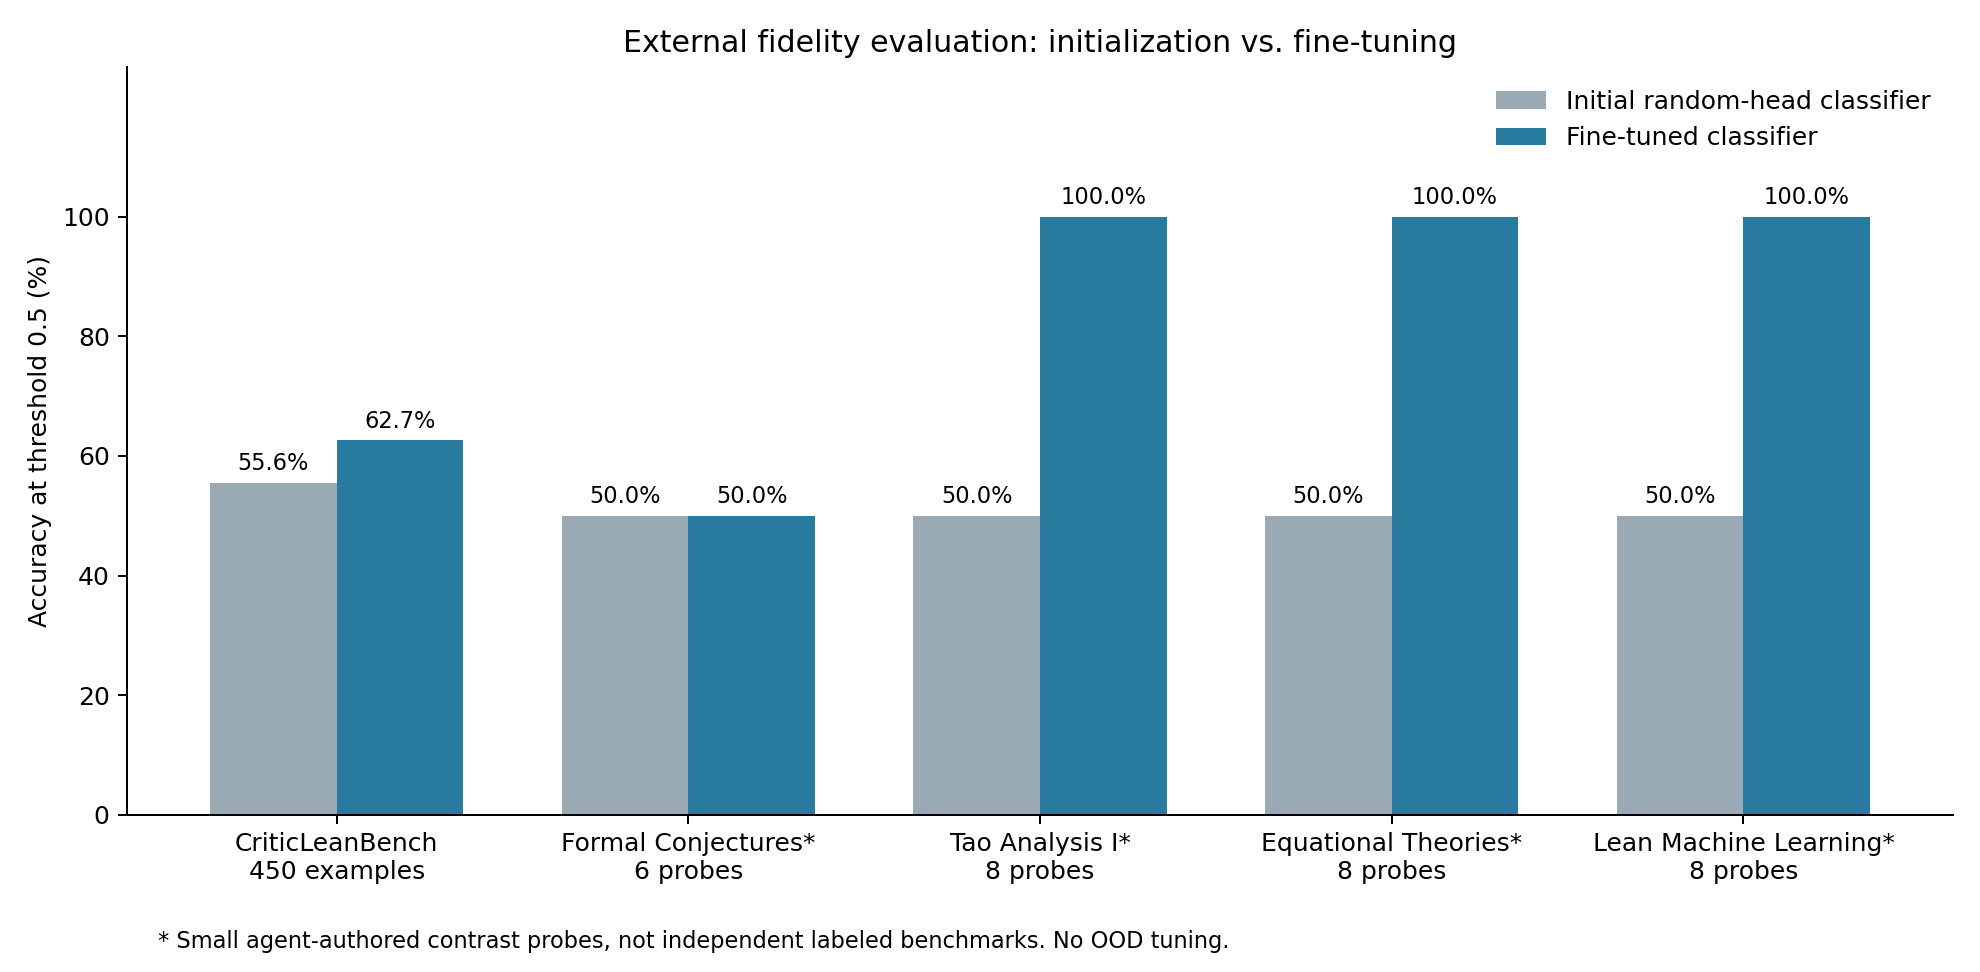

In [6]:
ood = json.loads((ROOT / "reports/ood-comparison.json").read_text())
external = pd.DataFrame(ood["results"])
display(external.pivot(index="dataset", columns="model", values="accuracy").map(lambda x: f"{x:.2%}"))
display(external[["dataset", "model", "n", "groups", "correct", "balanced_accuracy", "tp", "tn", "fp", "fn"]])
print("Paired CriticLeanBench accuracy change:", ood["critic_accuracy_delta"])
from IPython.display import Image
display(Image(filename=str(ROOT / "reports/ood-accuracy.png")))

### What transfers, and what does not

CriticLeanBench accuracy rises **55.56% → 62.67%**, compared with **80.85%** on the ID test. The +7.11-point change has a paired group-bootstrap 95% interval of **−0.66 to +14.96 points**; it includes zero. Balanced accuracy improves **50.05% → 65.25%**. The trained model catches **177/200 incorrect** formulations but recognizes only **105/250 faithful** ones at threshold 0.5.

The frozen ID acceptance gate accepts only **2/450**, with no observed errors. This small sample cannot establish reliability. Gate thresholds below differ: initial random head uses uncalibrated 0.5; fine-tuned uses the existing ID temperature and 0.8275 threshold. The curves describe outcomes, and must not be used to retrospectively pick an OOD threshold.

The tiny synthetic sets are diagnostic only: 100% on simple mutations is not evidence of broad generalization. Formal Conjectures remains at 50%, with all its probes classified as unfaithful by the fine-tuned model. Prompted Qwen and team optimization evaluations remain unmeasured.


,dataset,model,gate_threshold,coverage,accepted,wrong_accepted,accepted_error,faithful_recall,brier
0,CriticLeanBench,unfine_tuned,0.500000,0.995556,448,199,0.444196,0.996,0.314096
1,CriticLeanBench,fine_tuned,0.827533,0.004444,2,0,0.000000,0.008,0.224185
2,Formal Conjectures probes,unfine_tuned,0.500000,1.000000,6,3,0.500000,1.000,0.387422
3,Formal Conjectures probes,fine_tuned,0.827533,0.000000,0,0,NaN,0.000,0.192451
4,Tao Analysis I probes,unfine_tuned,0.500000,1.000000,8,4,0.500000,1.000,0.382901
5,Tao Analysis I probes,fine_tuned,0.827533,0.250000,2,0,0.000000,0.500,0.031797
6,Tao Equational Theories probes,unfine_tuned,0.500000,1.000000,8,4,0.500000,1.000,0.408573
7,Tao Equational Theories probes,fine_tuned,0.827533,0.000000,0,0,NaN,0.000,0.086219
8,Lean Machine Learning probes,unfine_tuned,0.500000,1.000000,8,4,0.500000,1.000,0.393327
9,Lean Machine Learning probes,fine_tuned,0.827533,0.000000,0,0,NaN,0.000,0.062197


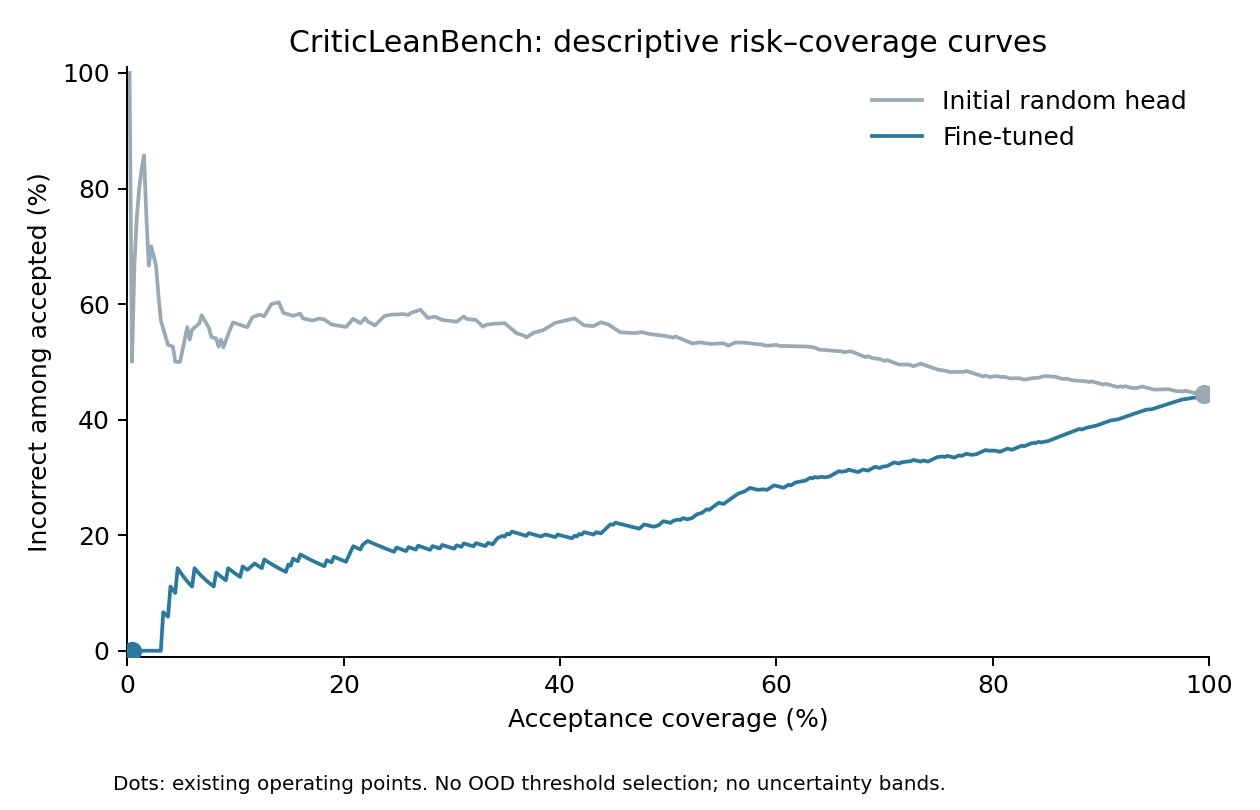

NaN accepted_error means no candidates were accepted, not zero error.
Modal audit: https://modal.com/apps/arin06/main/ap-On0lGR9m6ovXIR1GsZdAiS
Model inference seconds: 25.168637990951538


In [7]:
display(external[["dataset", "model", "gate_threshold", "coverage", "accepted", "wrong_accepted", "accepted_error", "faithful_recall", "brier"]])
display(Image(filename=str(ROOT / "reports/ood-risk-coverage.png")))
print("NaN accepted_error means no candidates were accepted, not zero error.")
print("Modal audit:", ood["app_url"])
print("Model inference seconds:", ood["inference_seconds"])